In [220]:
!python -m pip install numpy pandas \
    qiskit-aer qiskit-algorithms qiskit-machine-learning qiskit-ibm-runtime \
    pylatexenc ucimlrepo \
    xgboost catboost seaborn libsvm-official \
    jinja2


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [221]:
import sys
import os

# Add project root (210226) to Python path
sys.path.append(os.path.abspath(".."))

from utils.prepare_data import prepare_data

In [222]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [223]:
import warnings
from qiskit.transpiler import generate_preset_pass_manager
warnings.filterwarnings('ignore')

In [ ]:
from dotenv import load_dotenv
load_dotenv()

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

ibmq_token = os.getenv('IBMQ_TOKEN')

QiskitRuntimeService.save_account(
  token=ibmq_token,
  overwrite=True
)

In [225]:
import sys
import importlib

def reload_package(package_name):
    modules_to_reload = [
        name for name in sys.modules
        if name.startswith(package_name)
    ]

    for name in sorted(modules_to_reload, reverse=True):
        importlib.reload(sys.modules[name])

# Usage
reload_package("model")
reload_package("utils")

In [226]:
dataset_path = '../dataset/reduced_dataset.csv'
feature_cols = [
        "MQ3", 
        "TGS822", 
        "TGS2602", 
        "MQ5", 
        "MQ138", 
        "TGS2620", 
        "TGS813", 
        "TGS2600", 
        "TGS2611", 
        "TGS2603",
        "Humidity",
        "Celsius",
    ]
target_cols = "Kategori"

quantum_kernel_types = [
    # 'full', 
    'linear', 
    # 'circular', 
    # 'pauli_x', 
    # 'pauli_y', 
    # 'pauli_z'
]
kernel_types = [
    'linear', 
    'poly', 
    'rbf', 
    'sigmoid'
]

In [227]:
import pandas as pd
data = pd.read_csv(dataset_path)
data.head(10)

,MQ3,TGS822,TGS2602,MQ5,MQ138,TGS2620,TGS813,TGS2600,TGS2611,TGS2603,Humidity,Celsius,Chop_ID,Sampling_ID,Aroma,Taste,Color,Appearance,Dreg,Kategori,Standar Kualitas,MQ3_mean,MQ3_min,MQ3_max,MQ3_std,MQ3_skew,MQ3_kurtosis,MQ3_auc,TGS822_mean,TGS822_min,TGS822_max,TGS822_std,TGS822_skew,TGS822_kurtosis,TGS822_auc,TGS2602_mean,TGS2602_min,TGS2602_max,TGS2602_std,TGS2602_skew,TGS2602_kurtosis,TGS2602_auc,MQ5_mean,MQ5_min,MQ5_max,MQ5_std,MQ5_skew,MQ5_kurtosis,MQ5_auc,MQ138_mean,MQ138_min,MQ138_max,MQ138_std,MQ138_skew,MQ138_kurtosis,MQ138_auc,TGS2620_mean,TGS2620_min,TGS2620_max,TGS2620_std,TGS2620_skew,TGS2620_kurtosis,TGS2620_auc,TGS813_mean,TGS813_min,TGS813_max,TGS813_std,TGS813_skew,TGS813_kurtosis,TGS813_auc,TGS2600_mean,TGS2600_min,TGS2600_max,TGS2600_std,TGS2600_skew,TGS2600_kurtosis,TGS2600_auc,TGS2611_mean,TGS2611_min,TGS2611_max,TGS2611_std,TGS2611_skew,TGS2611_kurtosis,TGS2611_auc,TGS2603_mean,TGS2603_min,TGS2603_max,TGS2603_std,TGS2603_skew,TGS2603_kurtosis,TGS2603_auc,Humidity_mean,Humidity_min,Humidity_max,Humidity_std,Humidity_skew,Humidity_kurtosis,Humidity_auc,Celsius_mean,Celsius_min,Celsius_max,Celsius_std,Celsius_skew,Celsius_kurtosis,Celsius_auc,Aroma_mean,Aroma_min,Aroma_max,Aroma_std,Aroma_auc,Taste_mean,Taste_min,Taste_max,Taste_std,Taste_auc,Color_mean,Color_min,Color_max,Color_std,Color_auc,Appearance_mean,Appearance_min,Appearance_max,Appearance_std,Appearance_auc,Dreg_mean,Dreg_min,Dreg_max,Dreg_std,Dreg_auc
0,90.0,47.0,48.0,92.0,84.0,50.0,533.0,200.0,529.0,339.0,49.1,39.1,GM625,GM625_4,2.8,33,2.8,3.7,2.7,A,Cacat Mutu,90.6,90.0,91,0.516398,-0.408248,-1.833333,815.0,46.9,46,48,0.737865,0.139942,-0.960433,423.0,48.7,48,50,0.823273,0.579314,-1.135716,437.5,92.0,91,93.0,0.666667,0.000000,-0.500000,827.5,85.9,84,87,1.100505,-0.326891,-1.244508,773.0,51.0,50,52,0.942809,0.000000,-1.750000,458.5,531.1,528,533,1.523884,-0.571906,-0.191983,4780.5,199.4,198.0,200,0.699206,-0.657843,-0.628099,1795.0,529.8,529,531,0.632456,0.111111,-0.444444,4768.5,340.3,339,341,0.823273,-0.579314,-1.135716,3062.0,49.19,49.0,49.3,0.119722,-6.224583e-01,-1.042365,442.75,39.12,39.1,39.2,0.042164,1.500000e+00,0.250000,352.05,2.8,2.8,2.8,4.681111e-16,25.2,33,33,33,0,297,2.8,2.8,2.8,4.681111e-16,25.2,3.7,3.7,3.7,0.000000e+00,33.3,2.7,2.7,2.7,4.681111e-16,24.3
1,87.0,42.0,41.0,104.0,89.0,44.0,552.0,250.0,545.0,355.0,48.0,39.0,GM615,GM615_5,3.1,37,3.2,3.2,3.8,A,Baik,87.2,86.0,88,0.632456,-0.111111,-0.444444,784.5,42.1,41,43,0.737865,-0.139942,-0.960433,379.5,42.3,41,44,0.823273,0.680065,0.154260,381.0,103.5,103,104.0,0.527046,0.000000,-2.000000,931.5,88.2,87,90,1.135292,0.557086,-0.946492,793.0,44.8,44,46,0.632456,0.111111,-0.444444,403.0,551.5,551,552,0.527046,0.000000,-2.000000,4963.5,250.2,249.0,251,0.788811,-0.343622,-1.153061,2251.5,545.4,544,547,1.074968,0.271545,-1.044379,4908.0,354.2,353,355,0.632456,-0.111111,-0.444444,3187.5,47.86,47.5,48.1,0.250333,-8.188584e-01,-1.239173,430.80,39.06,39.0,39.1,0.051640,-4.082483e-01,-1.833333,351.50,3.1,3.1,3.1,4.681111e-16,27.9,37,37,37,0,333,3.2,3.2,3.2,4.681111e-16,28.8,3.2,3.2,3.2,4.681111e-16,28.8,3.8,3.8,3.8,0.000000e+00,34.2
2,89.0,47.0,48.0,90.0,87.0,52.0,530.0,192.0,530.0,328.0,47.8,39.8,GM625,GM625_1,2.8,33,2.8,3.7,2.7,A,Cacat Mutu,89.0,88.0,90,0.471405,0.000000,2.000000,800.5,47.3,46,49,0.823273,0.680065,0.154260,425.5,48.1,47,49,0.875595,-0.188430,-1.526150,432.5,89.0,88,90.0,0.816497,0.000000,-1.333333,801.0,87.0,86,88,0.666667,0.000000,-0.500000,782.5,51.0,50,52,0.816497,0.000000,-1.333333,458.0,530.1,526,533,2.378141,-0.542340,-1.051355,4770.0,192.7,191.0,194,0.823273,-0.680065,0.154260,1734.5,529.5,529,531,0.707107,0.993808,-0.222222,4764.5,327.2,326,328,0.788811,-0.343622,-1.153061,2944.0,47.83,47.7,47.9,0.067495,-3.656751e-01,-0.705532,430.55,39.68,39.6,39.8,0.063246,1.111111e-01,-0.444444,357.10,2.8,2.8,2.8,4.681111e-16,25.2,33,33,33,0,297,2.8,2.8,2.8,4.681111e-16,25.2,3.7,3.7,3.7,0.000000e+00,33.3,2.7,2.7,2.7,4.681111e-16,24.3
3,99.0,56.0,59.0,98.0,98.0,61.0,532.0,212.0,529

In [228]:
data.describe()

,MQ3,TGS822,TGS2602,MQ5,MQ138,TGS2620,TGS813,TGS2600,TGS2611,TGS2603,Humidity,Celsius,Aroma,Taste,Color,Appearance,Dreg,MQ3_mean,MQ3_min,MQ3_max,MQ3_std,MQ3_skew,MQ3_kurtosis,MQ3_auc,TGS822_mean,TGS822_min,TGS822_max,TGS822_std,TGS822_skew,TGS822_kurtosis,TGS822_auc,TGS2602_mean,TGS2602_min,TGS2602_max,TGS2602_std,TGS2602_skew,TGS2602_kurtosis,TGS2602_auc,MQ5_mean,MQ5_min,MQ5_max,MQ5_std,MQ5_skew,MQ5_kurtosis,MQ5_auc,MQ138_mean,MQ138_min,MQ138_max,MQ138_std,MQ138_skew,MQ138_kurtosis,MQ138_auc,TGS2620_mean,TGS2620_min,TGS2620_max,TGS2620_std,TGS2620_skew,TGS2620_kurtosis,TGS2620_auc,TGS813_mean,TGS813_min,TGS813_max,TGS813_std,TGS813_skew,TGS813_kurtosis,TGS813_auc,TGS2600_mean,TGS2600_min,TGS2600_max,TGS2600_std,TGS2600_skew,TGS2600_kurtosis,TGS2600_auc,TGS2611_mean,TGS2611_min,TGS2611_max,TGS2611_std,TGS2611_skew,TGS2611_kurtosis,TGS2611_auc,TGS2603_mean,TGS2603_min,TGS2603_max,TGS2603_std,TGS2603_skew,TGS2603_kurtosis,TGS2603_auc,Humidity_mean,Humidity_min,Humidity_max,Humidity_std,Humidity_skew,Humidity_kurtosis,Humidity_auc,Celsius_mean,Celsius_min,Celsius_max,Celsius_std,Celsius_skew,Celsius_kurtosis,Celsius_auc,Aroma_mean,Aroma_min,Aroma_max,Aroma_std,Aroma_auc,Taste_mean,Taste_min,Taste_max,Taste_std,Taste_auc,Color_mean,Color_min,Color_max,Color_std,Color_auc,Appearance_mean,Appearance_min,Appearance_max,Appearance_std,Appearance_auc,Dreg_mean,Dreg_min,Dreg_max,Dreg_std,Dreg_auc
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.00000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.00000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.00000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.00000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.00000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,1.500000e+01,15.000000,15.000000,15.000000,15.000000,15.0,15.000000,15.000000,15.000000,15.000000,1.500000e+01,15.000000,15.000000,15.000000,15.000000,1.500000e+01,15.000000,15.000000,15.000000,15.000000,1.500000e+01,15.000000
mean,92.000000,49.933333,50.066667,97.133333,90.866667,53.20000,533.866667,213.333333,530.933333,333.933333,48.253333,39.406667,2.780000,33.800000,2.860000,3.126667,2.866667,92.106667,91.400000,92.933333,0.600590,0.164180,-0.973720,828.866667,49.973333,48.933333,51.133333,0.826944,0.133502,-1.048376,450.033333,50.16000,49.000000,51.533333,0.885715,0.125029,-0.758905,451.166667,97.040000,96.066667,97.933333,0.665063,-0.145058,-0.378489,873.233333,91.340000,90.20000,92.533333,0.837270,0.076714,-0.952561,821.900000,53.373333,52.400000,54.400000,0.749014,0.130091,-0.952157,480.200000,533.680000,531.066667,535.80000,1.554065,-0.251557,-0.536770,4803.000000,213.540000,212.333333,214.400000,0.713706,-0.345505,-0.513090,1921.866667,531.046667,530.066667,532.266667,0.818196,0.176733,-0.782613,4779.266667,333.793333,332.533333,334.866667,0.814035,-0.141809,-0.481370,3004.20000,48.283333,48.153333,48.406667,0.101635,-0.172240,-0.406612,434.556667,39.398000,39.333333,39.460000,0.050792,-0.014353,0.050638,354.583333,2.780000,2.780000,2.780000,4.681111e-16,25.020000,33.800000,33.800000,33.800000,0.0,304.200000,2.860000,2.860000,2.860000,4.369037e-16,25.740000,3.126667,3.126667,3.126667,3.120741e-16,28.140000,2.866667,2.866667,2.866667,4.056963e-16,25.800000
std,4.551295,4.949266,5.824415,12.217474,5.194319,5.63408,

Text(0.5, 1.0, 'Histogram for the Kategori')

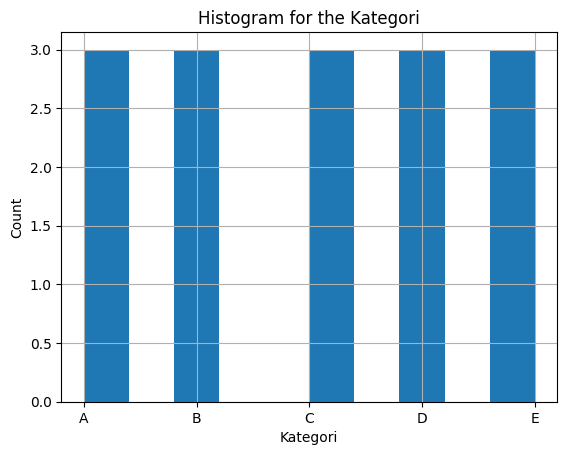

In [229]:
import matplotlib.pyplot as plt
data['Kategori'].hist()
plt.xlabel('Kategori')
plt.ylabel('Count')
plt.title('Histogram for the Kategori')

## Preprocess

In [230]:
from utils.preprocess import preprocess
data = preprocess(data)

In [231]:
distinct_classes_df = data.drop_duplicates(subset=['Kategori'])
distinct_classes_df

,MQ3,TGS822,TGS2602,MQ5,MQ138,TGS2620,TGS813,TGS2600,TGS2611,TGS2603,Humidity,Celsius,Chop_ID,Sampling_ID,Aroma,Taste,Color,Appearance,Dreg,Kategori,Standar Kualitas,MQ3_mean,MQ3_min,MQ3_max,MQ3_std,MQ3_skew,MQ3_kurtosis,MQ3_auc,TGS822_mean,TGS822_min,TGS822_max,TGS822_std,TGS822_skew,TGS822_kurtosis,TGS822_auc,TGS2602_mean,TGS2602_min,TGS2602_max,TGS2602_std,TGS2602_skew,TGS2602_kurtosis,TGS2602_auc,MQ5_mean,MQ5_min,MQ5_max,MQ5_std,MQ5_skew,MQ5_kurtosis,MQ5_auc,MQ138_mean,MQ138_min,MQ138_max,MQ138_std,MQ138_skew,MQ138_kurtosis,MQ138_auc,TGS2620_mean,TGS2620_min,TGS2620_max,TGS2620_std,TGS2620_skew,TGS2620_kurtosis,TGS2620_auc,TGS813_mean,TGS813_min,TGS813_max,TGS813_std,TGS813_skew,TGS813_kurtosis,TGS813_auc,TGS2600_mean,TGS2600_min,TGS2600_max,TGS2600_std,TGS2600_skew,TGS2600_kurtosis,TGS2600_auc,TGS2611_mean,TGS2611_min,TGS2611_max,TGS2611_std,TGS2611_skew,TGS2611_kurtosis,TGS2611_auc,TGS2603_mean,TGS2603_min,TGS2603_max,TGS2603_std,TGS2603_skew,TGS2603_kurtosis,TGS2603_auc,Humidity_mean,Humidity_min,Humidity_max,Humidity_std,Humidity_skew,Humidity_kurtosis,Humidity_auc,Celsius_mean,Celsius_min,Celsius_max,Celsius_std,Celsius_skew,Celsius_kurtosis,Celsius_auc,Aroma_mean,Aroma_min,Aroma_max,Aroma_std,Aroma_auc,Taste_mean,Taste_min,Taste_max,Taste_std,Taste_auc,Color_mean,Color_min,Color_max,Color_std,Color_auc,Appearance_mean,Appearance_min,Appearance_max,Appearance_std,Appearance_auc,Dreg_mean,Dreg_min,Dreg_max,Dreg_std,Dreg_auc
0,-0.454859,-0.613483,-0.367282,-0.434910,-1.368355,-0.587907,-0.148964,-0.826757,-0.395226,0.586109,0.329369,-0.235901,1,2,0.121867,-0.445362,-0.306186,1.783941,-0.490290,0,1,-0.330916,-0.305215,-0.416674,-0.674351,-1.262162,-0.837968,-0.337345,-0.596740,-0.563178,-0.619495,-0.609652,0.019816,0.169835,-0.583262,-0.285222,-0.190347,-0.303157,-0.367671,0.816077,-0.720548,-0.295990,-0.427761,-0.430376,-0.422726,0.011366,0.194402,-0.106210,-0.430995,-1.090072,-1.221571,-1.088343,1.333308,-1.163097,-0.883489,-1.088189,-0.439552,-0.444343,-0.451626,1.497124,-0.277715,-1.067738,-0.443239,-0.422961,-0.441736,-0.498940,-0.043376,-0.773318,0.345948,-0.408553,-0.883095,-0.887627,-0.899344,-0.089620,-0.655783,-0.121820,-0.881164,-0.263400,-0.227093,-0.261876,-1.480428,-0.111429,0.553170,-0.252592,0.745337,0.738631,0.709880,0.083764,-0.650441,-0.781701,0.736949,0.351669,0.332163,0.344083,0.247577,-0.401461,-0.283519,0.353196,-0.212470,-0.177663,-0.197728,-0.613199,1.156214,0.094055,-0.215151,0.121867,0.121867,0.121867,-9.860761e-32,0.121867,-0.445362,-0.445362,-0.445362,0.0,-0.445362,-0.306186,-0.306186,-0.306186,0.267261,-0.306186,1.783941,1.783941,1.783941,-1.414214,1.783941,-0.490290,-0.490290,-0.490290,0.392232,-0.490290
3,1.592006,1.268793,1.587606,0.073426,1.421496,1.433023,-0.320844,-0.082676,-0.395226,0.354750,0.601683,-0.082052,6,9,-1.096800,-1.002064,-0.816497,-0.705279,-0.784465,1,1,1.426161,1.438868,1.523014,0.789873,1.088489,0.336918,1.414253,1.344930,1.356746,1.357616,1.146262,0.204889,-1.541305,1.336973,1.492529,1.522774,1.476242,-0.570589,0.392679,-0.753715,1.501607,0.064504,0.079280,0.091400,-0.231065,0.343310,-0.057650,0.068482,1.414689,1.536815,1.271919,-1.625248,0.955404,-2.665389,1.415313,1.264329,1.221943,1.430149,0.307442,2.045205,2.803718,1.262313,-0.291810,-0.441736,-0.320747,0.904286,-1.026054,-0.419566,-0.272369,-0.071197,-0.082570,-0.087436,-0.089620,-0.655783,-0.121820,-0.068530,-0.200015,-0.227093,-0.261876,-0.640271,-0.537726,-0.290874,-0.205671,0.332958,0.395967,0.362656,-1.261222,0.754479,-0.267791,0.341700,0.572755,0.606785,0.536667,-0.684361,-0.210449,-0.636256,0.570889,-0.097828,-0.101522,-0.121679,-0.176762,-0.655482,-0.607999,-0.096252,-1.096800,-1.096800,-1.096800,-9.860761e-32,-1.096800,-1.002064,-1.002064,-1.002064,0.0,-1.002064,-0.816497,-0.816497,-0.816497,0.267261,-0.816497,-0.705279,-0.705279,-0.705279,0.707107,-0.705279,-0.784465,-0.784465,-0.784465,0.392232,-0.784465
6,-1.592006,-1.659191,-1.611302,-1.451584,-1.368355,-1.873953,0.882322,-0.144682,1.240192,0.239071,

In [232]:
X = data[feature_cols]
y = data[target_cols]


cat_features = [
    i for i, col in enumerate(X.columns)
    if X[col].dtype == 'object'
]

print(X.shape, y.shape)

(15, 12) (15,)


## PCA

In [233]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
def plot_pca_variance(X, n_components, threshold=0.95):
  pca = PCA(n_components=n_components)
  pca.fit(X)

  cumvar = np.cumsum(pca.explained_variance_ratio_)
  n_optimal = np.argmax(cumvar >= threshold) + 1

  plt.figure(figsize=(8, 5))
  plt.plot(range(1, n_components + 1), cumvar, marker='o', color='blue')
  plt.axhline(y=threshold, color='gray', linestyle='--', linewidth=1)
  plt.xlabel('Number of Principal Components')
  plt.ylabel('Cumulative Explained Variance')
  plt.xticks(range(1, n_components + 1))
  plt.grid(True)
  plt.tight_layout()
  plt.show()

  print(f'Optimal number of components to retain {threshold*100:.0f}% variance: {n_optimal}')

  return n_optimal

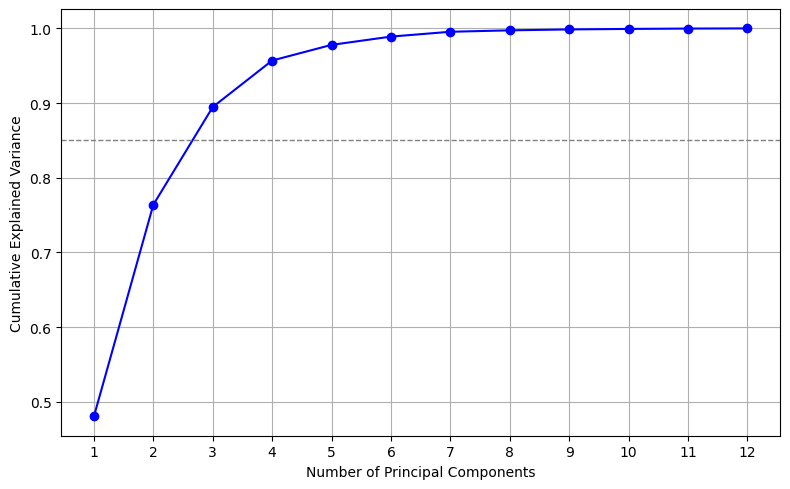

Optimal number of components to retain 85% variance: 3


In [234]:
n_optimal = plot_pca_variance(X, n_components=X.shape[1], threshold=0.85)

In [235]:
pca_final = PCA(n_components=n_optimal)
X = pca_final.fit_transform(X)
print(X.shape)

(15, 3)


In [236]:
from utils.prepare_data import prepare_data
from utils.preprocess import preprocess
from model.evaluate import evaluate_svc, evaluate_xgboost, evaluate_catboost, evaluate_quantum, evaluate_libsvm
from sklearn.model_selection import StratifiedKFold, KFold

state = 42
n_splits = 5

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=state, stratify=y)
all_results = []

skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=state)

for fold, (train_index, test_index) in enumerate(skf.split(X, y), start=1):
    print(f"\rFold: {fold}/{n_splits}     ", end="")

    X_train_fold, X_test_fold = X[train_index], X[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    data_obj = {
        'X_train': X_train_fold,
        'y_train': y_train_fold,
        'X_test': X_test_fold,
        'y_test': y_test_fold,
        'cat_features': cat_features
        # 'classes': sorted(y.unique())
        # 'X_test': X_test,  # We pass the test set through just so it gets transformed
        # 'y_test': y_test
    }

    # preprocessed_data = preprocess(data_raw)
    last_data = data_obj

    model_outputs = {
        # "SVC": evaluate_svc(data_obj, kernel_types),
        # "XGBoost": evaluate_xgboost(data_obj, kernel_types),
        # "CatBoost": evaluate_catboost(data_obj, kernel_types),
        "Quantum": evaluate_quantum(data_obj, quantum_kernel_types, use_hardware=True),
        # "LibSVM": evaluate_libsvm(preprocessed_data, kernel_types)
    }

    for model_name, results in model_outputs.items():
        for r in results:
            r_copy = r.copy()
            r_copy["model"] = model_name
            r_copy["random_state"] = state
            all_results.append(r_copy)

Fold: 1/5     

qiskit_runtime_service.__init__:WARNING:2026-04-14 20:41:29,957: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-14 20:41:30,574: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-14 20:41:57,416: Using instance: open-instance, plan: open


Using backend: ibm_fez
Fold: 2/5     

qiskit_runtime_service.__init__:WARNING:2026-04-14 20:53:35,562: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-14 20:53:36,463: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-14 20:53:39,424: Using instance: open-instance, plan: open


Using backend: ibm_marrakesh


In [237]:
from catboost import CatBoostClassifier
model = CatBoostClassifier()

,Dataset,N
0,Train,8
1,Test,7


,Train,Test
Kategori,,
0,2,1
1,1,2
2,2,1
3,1,2
4,2,1


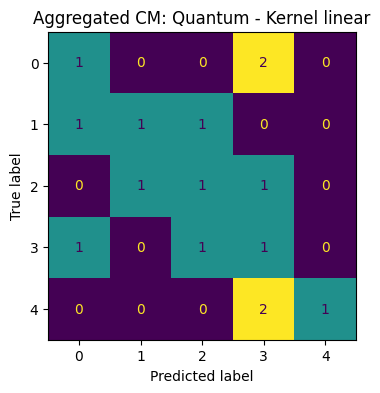

In [238]:
from utils.aggregate_result import aggregate_results
from utils.report import report
from utils.conf_matrix import plot_conf_matrix

# 1. Agregasi hasil
final_aggregated_results = aggregate_results(all_results)

# 2. Print tabel metrik
# (Pastikan fungsi report Anda di-update juga jika ingin print kolom 'model')
report(final_aggregated_results, last_data, is_aggregated=True)

# 3. Plot Grand Confusion Matrix
n = len(final_aggregated_results)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
if n == 1:
    axes = [axes]

for i, result in enumerate(final_aggregated_results):
    title = f"Aggregated CM: {result['model']} - Kernel {result['kernel']}"
    plot_conf_matrix(result['confusion_matrix_sum'], ax=axes[i], title=title)

# plt.tight_layout()
plt.show()